# **Feature Engineering**

Feature engineering is the process of creating new variables from existing features to improve model performance.

The original dataset contains booking details, customer information, and reservation history. New features are created to better capture customer behavior and booking characteristics that may influence cancellation decisions.

The following engineered features were developed:

1. Total Guests
2. Total Nights
3. Family Booking Indicator
4. Customer History

These features are expected to provide additional predictive information beyond the original dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\user\OneDrive\Desktop\Machine Learning Project\Data\hotel_bookings_cleaned_day_2.csv")

# **Feature 1 — Total Guests**

In [2]:
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

## Feature 1: Total Guests

### How was it created?

The total number of guests was calculated by combining:

- adults
- children
- babies

### Formula

Total Guests = Adults + Children + Babies

### Why may it help prediction?

The number of guests reflects the size of the travel group.

Larger groups often require more planning and coordination, which may influence cancellation behavior.

### Observed Relationship

The visualization indicates differences in booking behavior across various group sizes.

Guest count appears to contribute useful information for predicting hotel booking cancellations.

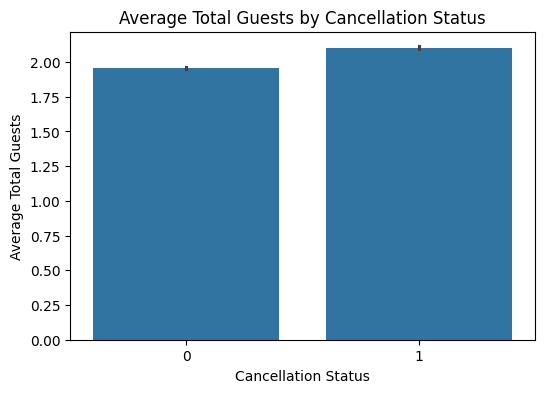

In [3]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='is_canceled',
    y='total_guests',
    data=df,
    estimator='mean'
)

plt.title('Average Total Guests by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Average Total Guests')

plt.show()

## Total Guests vs Cancellation

The chart compares the average number of guests between canceled and non-canceled bookings.

The visualization shows that canceled bookings have a slightly higher average number of guests compared to non-canceled bookings. This indicates that larger travel groups may be somewhat more likely to cancel their reservations.

### Interpretation

Group size can influence booking decisions because larger groups often require more planning, coordination, and flexibility.

The higher average guest count among canceled bookings suggests that group size may have a small impact on cancellation behavior. Therefore, the `total_guests` feature may provide useful information for predicting hotel booking cancellations when combined with other booking-related features.

# **Feature 2 — Total Nights**

In [4]:
df['total_nights'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

## Feature 2: Total Nights

### How was it created?

The total duration of stay was calculated by combining:

- stays_in_weekend_nights
- stays_in_week_nights

### Formula

Total Nights = Weekend Nights + Week Nights

### Why may it help prediction?

The duration of a reservation may affect a customer's commitment to travel plans.

Longer stays often require greater financial and logistical planning, which can influence cancellation decisions.

### Observed Relationship

The boxplot shows that canceled bookings tend to have slightly longer stay durations compared to non-canceled bookings.

This suggests that reservation length may be associated with cancellation behavior.

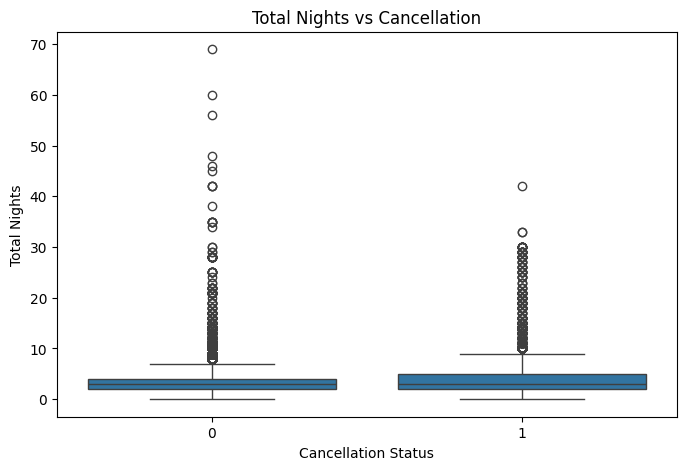

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_canceled',
    y='total_nights',
    data=df
)

plt.title('Total Nights vs Cancellation')
plt.xlabel('Cancellation Status')
plt.ylabel('Total Nights')

plt.show()

# **Feature 3 — Family Booking Indicator**

In [6]:
df['is_family'] = (
    (df['children'] > 0) |
    (df['babies'] > 0)
).astype(int)

## Feature 3: Family Booking Indicator

### How was it created?

A booking was classified as a family booking when:

- children > 0
or
- babies > 0

### Formula

Family Booking

- 1 = Family
- 0 = Non-Family

### Why may it help prediction?

Families often have different travel behaviors compared to solo travelers, couples, or business guests.

Their planning process, travel schedules, and booking decisions may influence cancellation patterns.

### Observed Relationship

The visualization shows that family bookings represent a smaller portion of total reservations.

Cancellation patterns differ slightly between family and non-family travelers, suggesting that family status may provide useful predictive information.

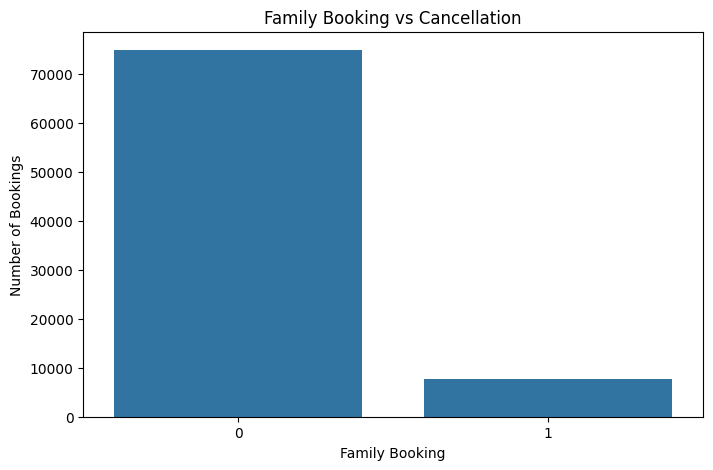

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='is_family',
    data=df
)

plt.title('Family Booking vs Cancellation')
plt.xlabel('Family Booking')
plt.ylabel('Number of Bookings')



plt.show()

# **Feature 4 — Customer History**

In [8]:
df['customer_history'] = (
    df['previous_cancellations'] +
    df['previous_bookings_not_canceled']
)

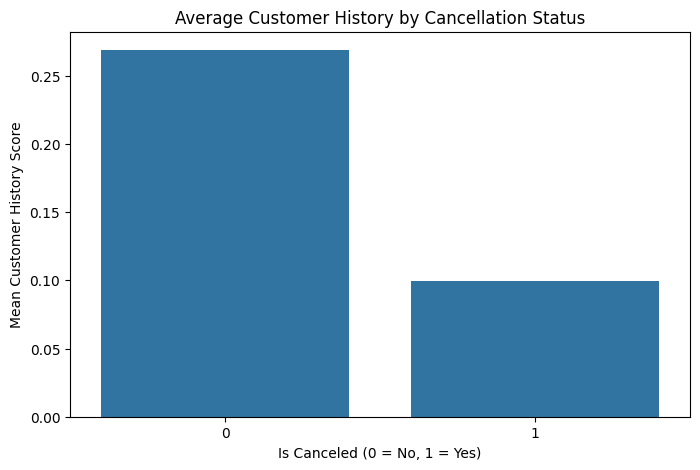

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Using a barplot to show the mean of customer history per category
sns.barplot(
    x='is_canceled',
    y='customer_history',
    data=df,
    errorbar=None # Removes confidence interval lines for a cleaner look
)

plt.title('Average Customer History by Cancellation Status')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Mean Customer History Score')

plt.show()

## Feature 4: Customer History

### How was it created?

Customer history was calculated by combining:

- previous_cancellations
- previous_bookings_not_canceled

### Formula

Customer History =
Previous Cancellations +
Previous Successful Bookings

### Why may it help prediction?

Previous booking activity reflects customer experience and loyalty.

Guests with a history of bookings may behave differently from first-time customers.

### Observed Relationship

The visualization indicates that customers with prior booking history tend to show different cancellation behavior compared to customers with little or no booking history.

This feature captures valuable information about customer loyalty and booking patterns.

# **Feature Correlation Analysis**

## Relationship Between Engineered Features

A correlation analysis was performed to examine the relationship between the newly created features and the target variable.

The correlation matrix helps identify which engineered features have stronger associations with booking cancellations and whether any features are highly correlated with each other.

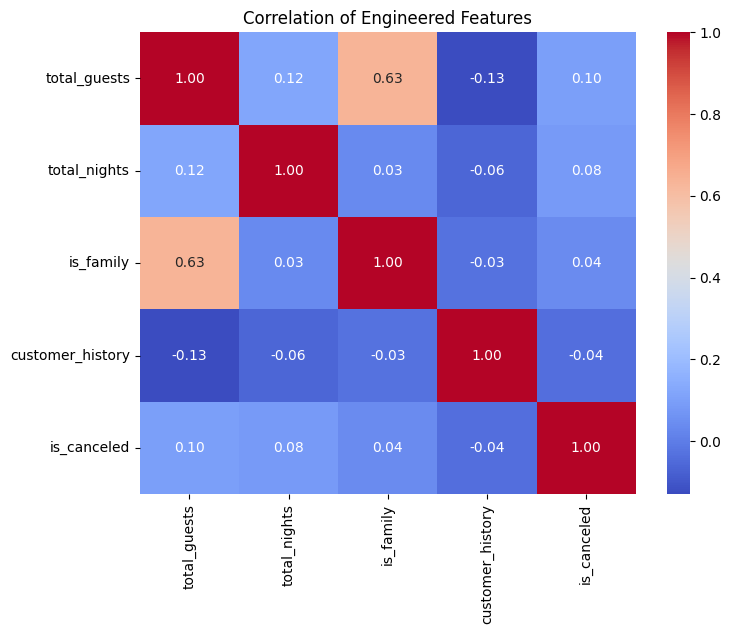

In [18]:
engineered_features = [
    'total_guests',
    'total_nights',
    'is_family',
    'customer_history',
    'is_canceled'
]

plt.figure(figsize=(8,6))

sns.heatmap(df[engineered_features].corr(),
            annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation of Engineered Features')
plt.show()

# Feature Engineering Summary

Four new features were created to improve the predictive capability of the hotel booking dataset.

| Feature | Type |
|----------|----------|
| total_guests | Aggregation |
| total_nights | Aggregation |
| is_family | Grouped Category |
| customer_history | Aggregation |

## Key Findings

### Total Guests
Bookings with a higher average number of guests showed a slightly greater tendency toward cancellation. Group size appears to influence booking behavior and travel planning decisions.

### Total Nights
Guests with longer reservation durations exhibited different cancellation patterns compared to shorter stays. Reservation length may contribute to cancellation likelihood.

### Family Booking Indicator
Family bookings accounted for a smaller proportion of reservations and demonstrated slightly different cancellation behavior compared to non-family travelers.

### Customer History
Customers with previous booking activity showed more stable booking behavior. Historical booking records provide valuable insight into customer loyalty and future reservation outcomes.

## Overall Impact

The engineered features successfully capture important aspects of:

- Guest characteristics
- Reservation duration
- Family travel behavior
- Customer loyalty and booking history

These features provide more meaningful information than the original variables alone and help uncover patterns related to hotel booking cancellations.

## Conclusion

Feature engineering enhanced the dataset by creating variables that better represent customer behavior and reservation characteristics. The newly created features are expected to improve the predictive performance of the classification model and provide deeper insights into the factors influencing booking cancellations.

The dataset is now prepared for model development and evaluation in the next phase of the project.

In [11]:
save_path = r"C:\Users\user\OneDrive\Desktop\Machine Learning Project\Data\hotel_bookings_feature_engineered.csv"

df.to_csv(save_path, index=False)

print("Feature Engineered Dataset Saved Successfully!")

Feature Engineered Dataset Saved Successfully!


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82479 entries, 0 to 82478
Data columns (total 62 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           82479 non-null  int64  
 1   is_canceled                     82479 non-null  int64  
 2   lead_time                       82479 non-null  int64  
 3   arrival_date_year               82479 non-null  int64  
 4   arrival_date_month              82479 non-null  int64  
 5   arrival_date_week_number        82479 non-null  int64  
 6   arrival_date_day_of_month       82479 non-null  int64  
 7   stays_in_weekend_nights         82479 non-null  int64  
 8   stays_in_week_nights            82479 non-null  int64  
 9   adults                          82479 non-null  int64  
 10  children                        82479 non-null  float64
 11  babies                          82479 non-null  int64  
 12  is_repeated_guest               82479 non-n